# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* None
* None
* None


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [1]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


None



In [3]:
# Nos conectamos a nuestro Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cargamos los datos:

df = pd.read_csv("/content/drive/MyDrive/Educación continua/Masters Inteligencia Aritficial/Inteligencia Artificial y Aprendizaje Automatico/IA Y AA Notebooks/Actividad 6 | Evaluación de una campaña publicitaria en redes sociales/SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [5]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************

column_names = {
    'laufkont'  : 'status',
    'laufzeit'  : 'duration',
    'moral'     : 'credit_history',
    'verw'      : 'purpose',
    'hoehe'     : 'amount',
    'sparkont'  : 'savings',
    'beszeit'   : 'employment_duration',
    'rate'      : 'installment_rate',
    'famges'    : 'personal_status_sex',
    'buerge'    : 'other_debtors',
    'wohnzeit'  : 'present_residence',
    'verm'      : 'property',
    'alter'     : 'age',
    'weitkred'  : 'other_installment_plans',
    'wohn'      : 'housing',
    'bishkred'  : 'number_credits',
    'beruf'     : 'job',
    'pers'      : 'people_liable',
    'telef'     : 'telephone',
    'gastarb'   : 'foreign_worker',
    'kredit'    : 'credit_risk'
}

df.rename(columns=column_names, inplace=True)




# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [6]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************

df['credit_risk'] = 1 - df['credit_risk']

# *********** Aquí termina la sección de agregar código *************

print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)

Nuevas Etiquetas:

* 0 : El préstamo fue reembolsado (buen cliente)
* 1 : El préstamo no fue reembolsado (mal cliente)


* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



la transformacion es adecuada porque en problemas de clasificacion binaria la convencion es que la clase positiva (1) represente el evento de interes que queremos detectar. en este caso los malos clientes son presisamente ese evento: un credito con riesgo de no pagarse. al etiquetarlos como 1 las metricas como recall y precisión se calcularan directamente sobre ellos. ademas. como son la clase minoritaria (300 de 1000). tiene sentido que sean la clase positiva para que las tecnicas de valanceo de datos y los modelos pongan atencion especial en detectarlos correctamente.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 3**

In [7]:
# Realiza una partición de 70-30 en entrenamiento y prueba y muestra el
# porcentaje de distribución de la variable de salida.

# Los nombres de los conjuntos train y test deberán ser como se indica
# al imprimir sus dimensiones en una celda más abajo:

# ************* Inlcuye aquí tu código:*****************************

from sklearn.model_selection import train_test_split

X = df.drop(columns='credit_risk')
y = df['credit_risk']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Distribución ytrain:\n{ytrain.value_counts()}")
print(f"\n% malos en train: {ytrain.mean()*100:.1f}%")
print(f"\nDistribución ytest:\n{ytest.value_counts()}")
print(f"\n% malos en test:  {ytest.mean()*100:.1f}%")

# *********** Aquí termina la sección de agregar código *************


Distribución ytrain:
credit_risk
0    490
1    210
Name: count, dtype: int64

% malos en train: 30.0%

Distribución ytest:
credit_risk
0    210
1     90
Name: count, dtype: int64

% malos en test:  30.0%


In [9]:
# Mostremos las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


# **Ejercicio 4**

In [10]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
list_paper_num = ['duration', 'amount', 'age', 'people_liable']

# Variables ordinales:
list_paper_ord = ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']

# Variables nominales/categóricas:
list_paper_cat = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'telephone', 'foreign_worker']

# *********** Aquí termina la sección de agregar código *************

# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

In [12]:


# Puedes incluir a continuación todas las celdas de código que requieras....

# Ejercicio 5: Análisis descriptivo

# ── 1. Estadísticas básicas de variables numéricas ──────────────────────────
print(" Estadísticas descriptivas - variables numéricas ")
Xtrain[list_paper_num].describe().round(2)



 Estadísticas descriptivas - variables numéricas 


,duration,amount,age,people_liable
count,700.00,700.00,700.00,700.00
mean,20.76,3212.21,35.79,1.84
std,12.06,2799.14,11.10,0.37
min,4.00,250.00,19.00,1.00
25%,12.00,1373.50,27.00,2.00
50%,18.00,2278.50,34.00,2.00
75%,24.00,3877.25,42.00,2.00
max,72.00,18424.00,75.00,2.00


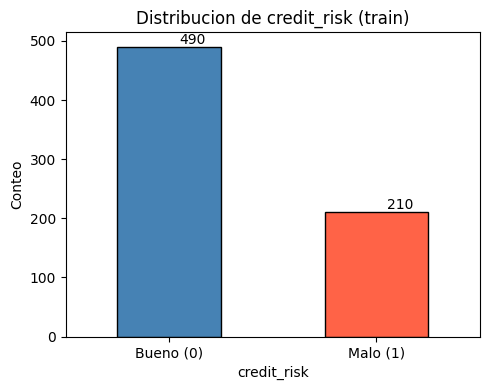

In [13]:
# 2. Distribucion de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 4))
ytrain.value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black')
ax.set_title('Distribucion de credit_risk (train)')
ax.set_xticklabels(['Bueno (0)', 'Malo (1)'], rotation=0)
ax.set_ylabel('Conteo')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+5))
plt.tight_layout()
plt.show()

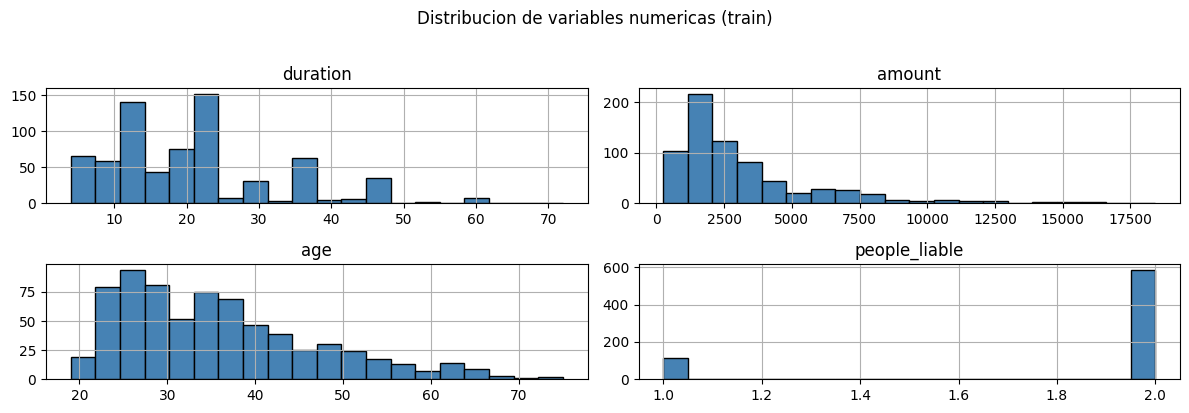

In [14]:
# 3. Histogramas de variables numericas
Xtrain[list_paper_num].hist(bins=20, figsize=(12, 4), color='steelblue', edgecolor='black')
plt.suptitle('Distribucion de variables numericas (train)', y=1.02)
plt.tight_layout()
plt.show()

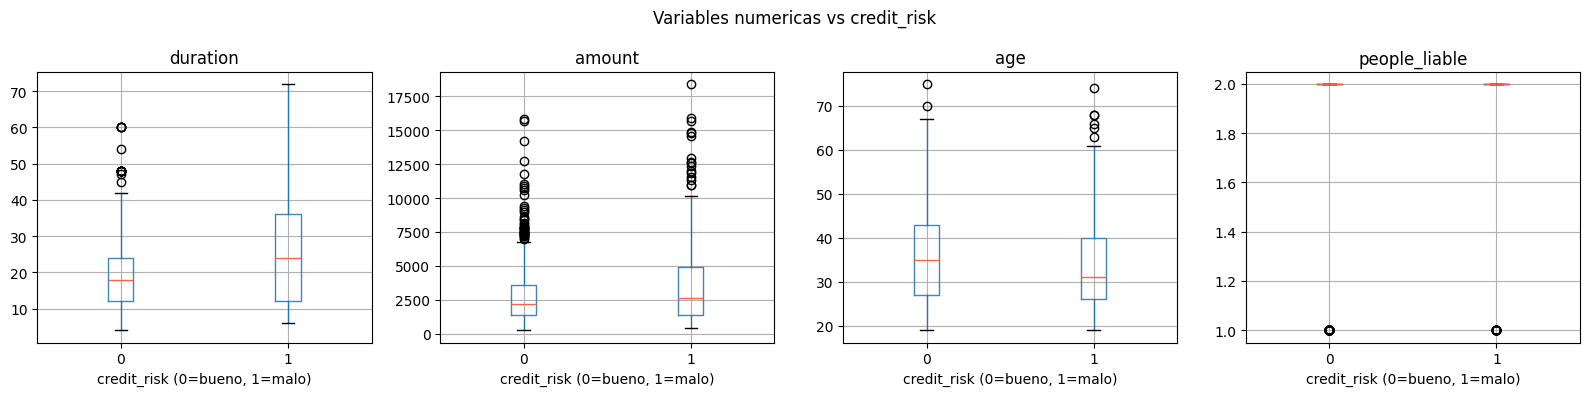

In [15]:
# 4. Boxplots de variables numericas vs credit_risk
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, list_paper_num):
    Xtrain_plot = Xtrain.copy()
    Xtrain_plot['credit_risk'] = ytrain.values
    Xtrain_plot.boxplot(column=col, by='credit_risk', ax=ax,
                        boxprops=dict(color='steelblue'),
                        medianprops=dict(color='tomato'))
    ax.set_title(col)
    ax.set_xlabel('credit_risk (0=bueno, 1=malo)')
plt.suptitle('Variables numericas vs credit_risk')
plt.tight_layout()
plt.show()

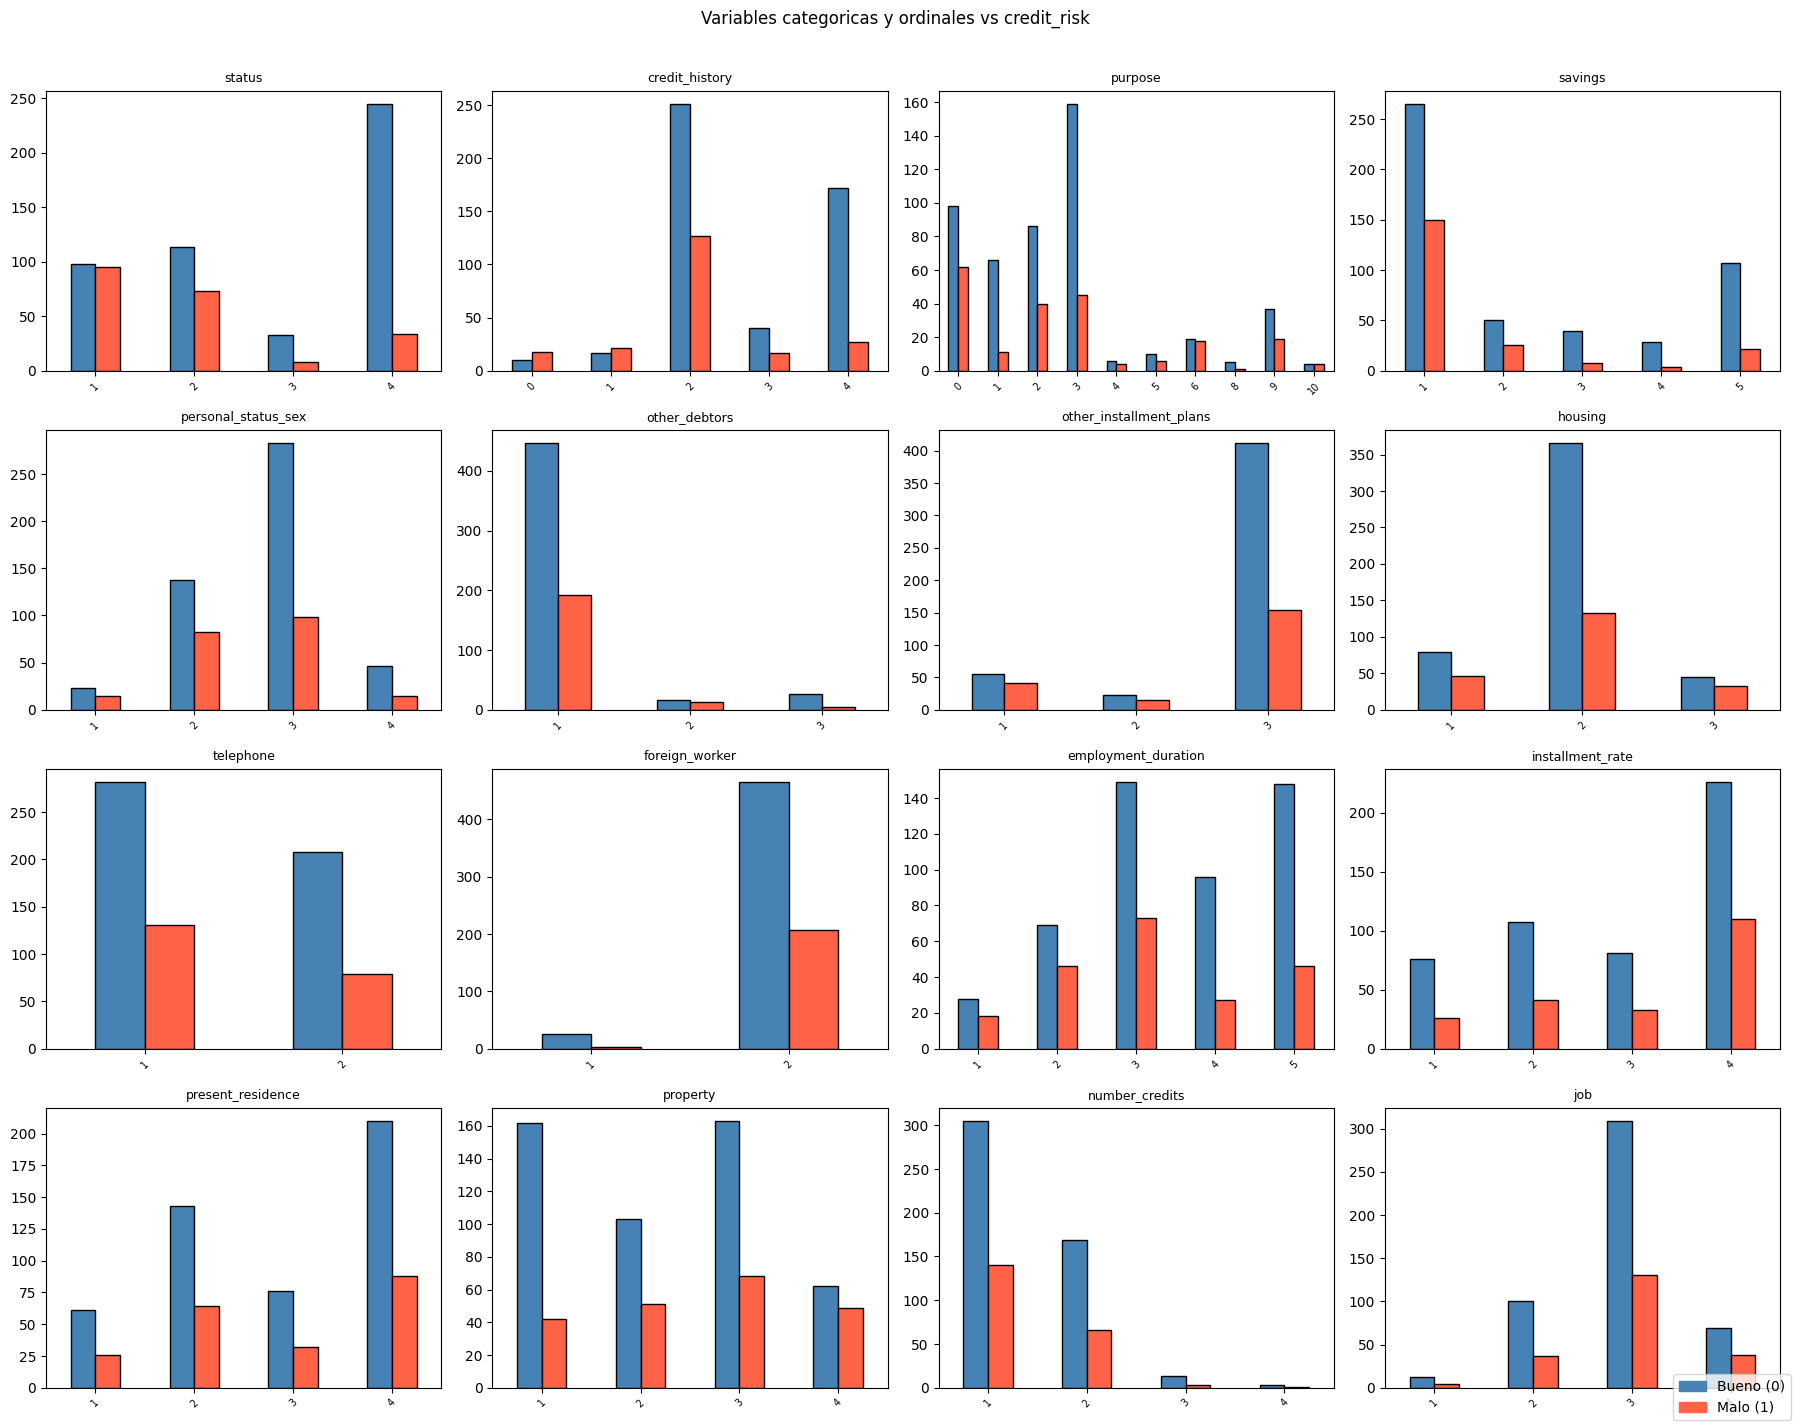

In [16]:
# 5. Frecuencias de variables categoricas y ordinales
all_cat = list_paper_cat + list_paper_ord
n = len(all_cat)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

Xtrain_plot = Xtrain.copy()
Xtrain_plot['credit_risk'] = ytrain.values

for ax, col in zip(axes, all_cat):
    ct = Xtrain_plot.groupby([col, 'credit_risk']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black', legend=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=45)

for ax in axes[n:]:
    ax.set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['steelblue','tomato']]
fig.legend(handles, ['Bueno (0)','Malo (1)'], loc='lower right', fontsize=10)
plt.suptitle('Variables categoricas y ordinales vs credit_risk', y=1.01)
plt.tight_layout()
plt.show()

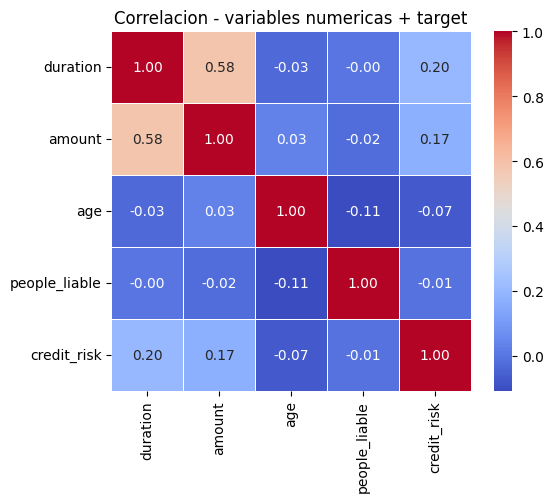

In [17]:
# 6. Correlacion entre variables numericas
import seaborn as sns

Xtrain_plot = Xtrain[list_paper_num].copy()
Xtrain_plot['credit_risk'] = ytrain.values

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(Xtrain_plot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlacion - variables numericas + target')
plt.tight_layout()
plt.show()

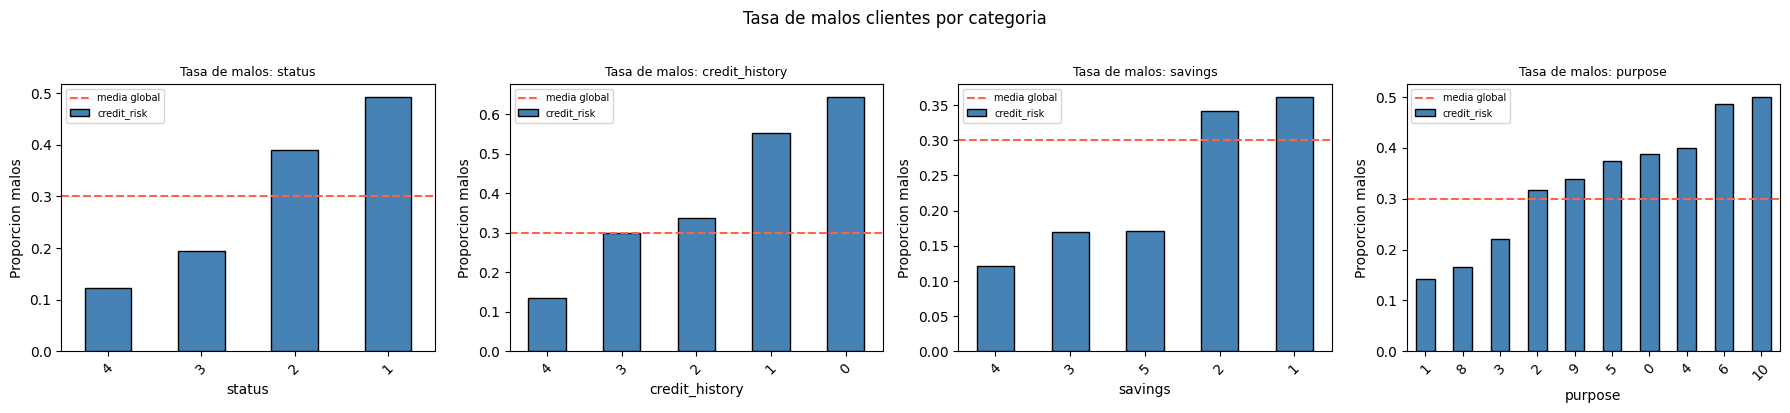

In [18]:
# 7. Tasa de malos clientes por categoria en variables clave
vars_interes = ['status', 'credit_history', 'savings', 'purpose']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
Xtrain_plot = Xtrain.copy()
Xtrain_plot['credit_risk'] = ytrain.values

for ax, col in zip(axes, vars_interes):
    tasa = Xtrain_plot.groupby(col)['credit_risk'].mean().sort_values()
    tasa.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Tasa de malos: {col}', fontsize=9)
    ax.set_ylabel('Proporcion malos')
    ax.axhline(ytrain.mean(), color='tomato', linestyle='--', label='media global')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

plt.suptitle('Tasa de malos clientes por categoria', y=1.02)
plt.tight_layout()
plt.show()

* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

el conjunto de entrenamiento cuenta con 700 registros de los cuales 490 son buenos clientes y 210 malos. lo que confirma el desbalance 70/30 que se mantiene correctamente tras el split estratificado.

en las variables numericas se observa que duration y amount presentan distribucion sesgada hacia la derecha con valores atipicos notables. esto justifica la aplicacion de normalizacion min-max antes del entrenamiento. age muestra una distribucion mas centrada entre los 25 y 45 años. people_liable es practicamente binaria con casi todos los valores en 1 o 2. lo que limita su aporte predictivo.

los boxplots muestran que los malos clientes tienden a tener creditos de mayor duracion y montos mas altos que los buenos clientes. lo que sugiere que estas dos variables tienen potencial discriminativo importante.

en cuanto a las variables categoricas. status es una de las mas informativas: los clientes sin cuenta de cheques (categoria 1) tienen una tasa de malos cercana al 50%. mientras que quienes tienen saldo mayor a 200 DM (categoria 4) bajan al 11%. credit_history tambien discrimina bien. los clientes con historial critico o deudas en otros bancos (categorias 0 y 1) presentan las tasas de incumplimiento mas altas. superando el 60%.

savings muestra que quienes no tienen cuenta de ahorros o tienen saldo desconocido (categoria 1) son los de mayor riesgo. mientras que quienes tienen mas de 500 DM ahorrados (categorias 4 y 5) estan por debajo de la media global. en purpose se observa que creditos para vacation. business y repairs tienen tasas de malos por encima del 40%.

en resumen. status. credit_history. savings y duration aparecen como las variables con mayor poder predictivo para identificar malos clientes. y seran probablemente las mas relevantes en los modelos.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [19]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 6a) Variables numericas: MinMaxScaler segun el articulo
num_pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
num_pipe_nombres = list_paper_num


# 6b) Variables categoricas/nominales: One-Hot-Encoding
nom_pipe = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
nom_pipe_nombres = list_paper_cat


# 6c) Variables ordinales: OrdinalEncoder
ord_pipe = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])
ord_nombres = list_paper_ord


# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers=[
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
], remainder='passthrough')


# *********** Aquí termina la sección de agregar código *************




In [20]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 51)


# **Ejercicio 7**

In [21]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento y validación
# en uno nuevo aumentado que llamaremos trainval para utilizar como entrenamiento:

# ************* Inlcuye aquí tu código:**************************

Xtt = pd.concat([Xtrain, Xtest], axis=0).reset_index(drop=True)
ytt = pd.concat([ytrain, ytest], axis=0).reset_index(drop=True)


# *********** Aquí termina la sección de agregar código *************

print('Dimensiones de los conjuntos concatenados:')
print(Xtt.shape, ytt.shape)

Dimensiones de los conjuntos concatenados:
(1000, 20) (1000,)


# **Ejercicio 8**

* **8a) Justifiquen el uso de la métrica exahustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

en el contexto de otorgamiento de creditos el error mas costoso es otorgar un credito a alguien que no va a pagar. es decir un falso negativo: predecir que un cliente es bueno cuando en realidad es malo. el recall mide precisamente la capacidad del modelo de detectar correctamente todos los malos clientes reales. calculandose como los verdaderos positivos entre todos los positivos reales.

si el modelo tiene recall bajo significa que esta dejando pasar muchos malos clientes sin detectarlos lo que se traduce directamente en perdidas economicas para la institucion financiera. por otro lado equivocarse en la direccion contraria es decir negar un credito a alguien que si hubiera pagado tiene un costo menor ya que simplemente se pierde una oportunidad de negocio pero no se incurre en una perdida directa.

por esta asimetria en los costos de los errores tiene sentido priorizar el recall como metrica principal buscando minimizar la cantidad de malos clientes que el modelo no logra identificar.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

In [23]:
# 8b) Determina el valor exacto del umbral para determinar si un modelo
#     está subentrenado y con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++



from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

estrategias = ['most_frequent', 'stratified', 'uniform', 'constant']

resultados_baseline = {}

for estrategia in estrategias:
    if estrategia == 'constant':
        clf = DummyClassifier(strategy=estrategia, constant=1, random_state=42)
    else:
        clf = DummyClassifier(strategy=estrategia, random_state=42)

    pipe = Pipeline(steps=[
        ('preprocessor', columnasTransformer),
        ('classifier', clf)
    ])

    scores = cross_val_score(pipe, Xtt, ytt, cv=5, scoring='recall')
    resultados_baseline[estrategia] = scores.mean()
    print(f"Estrategia: {estrategia:15s} | Recall promedio: {scores.mean():.4f} | Std: {scores.std():.4f}")

mejor_estrategia = max(resultados_baseline, key=resultados_baseline.get)
umbral_baseline  = resultados_baseline[mejor_estrategia]





# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Estrategia: most_frequent   | Recall promedio: 0.0000 | Std: 0.0000
Estrategia: stratified      | Recall promedio: 0.3233 | Std: 0.0429
Estrategia: uniform         | Recall promedio: 0.4933 | Std: 0.0271
Estrategia: constant        | Recall promedio: 1.0000 | Std: 0.0000


para este problema utilizaria **stratified** como baseline por las siguientes razones. primero es el mas honesto porque respeta la distribución real de clases del problema. segundo su recall de **0.32** representa lo que lograría un modelo que simplemente adivina conociendo la proporción de malos clientes. tercero cualquier modelo real debería superar ese 0.32 de forma consistente para justificar su uso. si un modelo entrenado no supera a una adivinanza informada entonces no está aprendiendo nada útil.

# **Ejercicio 9**

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

param_grids = {
    'LR':      {'m__C': [0.01, 0.1, 1, 10, 100],
                'm__solver': ['lbfgs', 'liblinear'],
                'm__max_iter': [200, 500, 1000]},
    'kNN':     {'m__n_neighbors': [3, 5, 7, 9, 11, 15],
                'm__weights': ['uniform', 'distance'],
                'm__metric': ['euclidean', 'manhattan']},
    'DTree':   {'m__max_depth': [3, 5, 7, 10, None],
                'm__min_samples_leaf': [1, 5, 10, 20],
                'm__criterion': ['gini', 'entropy']},
    'RF':      {'m__n_estimators': [100, 200, 300],
                'm__max_depth': [3, 5, 7, 10, None],
                'm__min_samples_leaf': [1, 5, 10]},
    'XGBoost': {'m__n_estimators': [100, 200, 300],
                'm__learning_rate': [0.01, 0.1, 0.2, 0.3],
                'm__max_depth': [3, 5, 7],
                'm__subsample': [0.7, 0.8, 1.0]},
    'MLP':     {'m__hidden_layer_sizes': [(50,), (100,), (100, 50), (200, 100)],
                'm__activation': ['relu', 'tanh'],
                'm__alpha': [0.0001, 0.001, 0.01],
                'm__max_iter': [500, 1000]},
    'SVM':     {'m__C': [0.1, 1, 10, 100],
                'm__kernel': ['rbf', 'linear'],
                'm__gamma': ['scale', 'auto']}
}

modelos_base = {
    'LR':      LogisticRegression(random_state=1),
    'kNN':     KNeighborsClassifier(),
    'DTree':   DecisionTreeClassifier(random_state=1),
    'RF':      RandomForestClassifier(random_state=1),
    'XGBoost': XGBClassifier(random_state=1, eval_metric='logloss'),
    'MLP':     MLPClassifier(random_state=1),
    'SVM':     SVC(random_state=1)
}

mi_uoSampling_search = SMOTE(random_state=42)
micv_search = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=5)
mejores_params = {}

for nombre, modelo in modelos_base.items():
    pipe = ImbPipeline(steps=[
        ('ct', columnasTransformer),
        ('uos', mi_uoSampling_search),
        ('m', modelo)
    ])
    search = RandomizedSearchCV(pipe,
                                param_distributions=param_grids[nombre],
                                n_iter=20,
                                scoring='recall',
                                cv=micv_search,
                                random_state=42,
                                n_jobs=-1)
    search.fit(Xtt, ytt)
    mejores_params[nombre] = {k.replace('m__',''): v for k, v in search.best_params_.items()}
    print(f">> {nombre}: {mejores_params[nombre]}")

>> LR: {'solver': 'liblinear', 'max_iter': 500, 'C': 0.1}
>> kNN: {'weights': 'distance', 'n_neighbors': 15, 'metric': 'euclidean'}
>> DTree: {'min_samples_leaf': 1, 'max_depth': 3, 'criterion': 'gini'}
>> RF: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 3}
>> XGBoost: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
>> MLP: {'max_iter': 500, 'hidden_layer_sizes': (50,), 'alpha': 0.0001, 'activation': 'tanh'}
>> SVM: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}


In [27]:
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.


# ************* Inlcuye aquí tu código:**************************

def mis_modelos():
    modelos, nombres = list(), list()

    # Regresión Logística:
    modelos.append(LogisticRegression(**mejores_params['LR'], random_state=1))
    nombres.append('LR')

    # k-Vecinos más Cercanos: aumentamos n_neighbors y usamos uniform para reducir sobreentrenamiento
    modelos.append(KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='manhattan'))
    nombres.append('kNN')

    # Árbol de decisiones:
    modelos.append(DecisionTreeClassifier(**mejores_params['DTree'], random_state=1))
    nombres.append('DTree')

    # Bosque Aleatorio:
    modelos.append(RandomForestClassifier(**mejores_params['RF'], random_state=1))
    nombres.append('RF')

    # XGBoosting:
    modelos.append(XGBClassifier(**mejores_params['XGBoost'], random_state=1, eval_metric='logloss'))
    nombres.append('XGBoost')

    # Red neuronal: capa pequeña, regularizacion alta y early stopping para reducir sobreentrenamiento
    modelos.append(MLPClassifier(hidden_layer_sizes=(50,), activation='relu',
                                 alpha=0.01, max_iter=500,
                                 early_stopping=True, random_state=1))
    nombres.append('MLP')

    # Máquina de Vectores de Soporte:
    modelos.append(SVC(**mejores_params['SVM'], random_state=1))
    nombres.append('SVM')

    return modelos, nombres


# Si se desea incluir alguna técnica de submuestreo y/o sobremuestreo:
mi_uoSampling = SMOTE(random_state=42)


# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # usi de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)

  # Definimos todas las métricas que desamos recuperar. En este caso comparemos
  # con la exactitud:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtt,
                          ytt,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.713 (0.040)
	 train_accuracy 0.741 (0.009)
	 test_recall 0.709 (0.054)
	 train_recall 0.749 (0.008)
>> kNN
	 test_accuracy 0.681 (0.033)
	 train_accuracy 0.752 (0.010)
	 test_recall 0.603 (0.043)
	 train_recall 0.744 (0.026)
>> DTree
	 test_accuracy 0.651 (0.049)
	 train_accuracy 0.697 (0.021)
	 test_recall 0.640 (0.102)
	 train_recall 0.703 (0.096)
>> RF
	 test_accuracy 0.707 (0.054)
	 train_accuracy 0.751 (0.011)
	 test_recall 0.667 (0.091)
	 train_recall 0.731 (0.021)
>> XGBoost
	 test_accuracy 0.690 (0.044)
	 train_accuracy 0.733 (0.013)
	 test_recall 0.712 (0.068)
	 train_recall 0.771 (0.025)
>> MLP
	 test_accuracy 0.679 (0.059)
	 train_accuracy 0.716 (0.045)
	 test_recall 0.690 (0.047)
	 train_recall 0.764 (0.035)
>> SVM
	 test_accuracy 0.709 (0.040)
	 train_accuracy 0.742 (0.010)
	 test_recall 0.721 (0.057)
	 train_recall 0.766 (0.014)


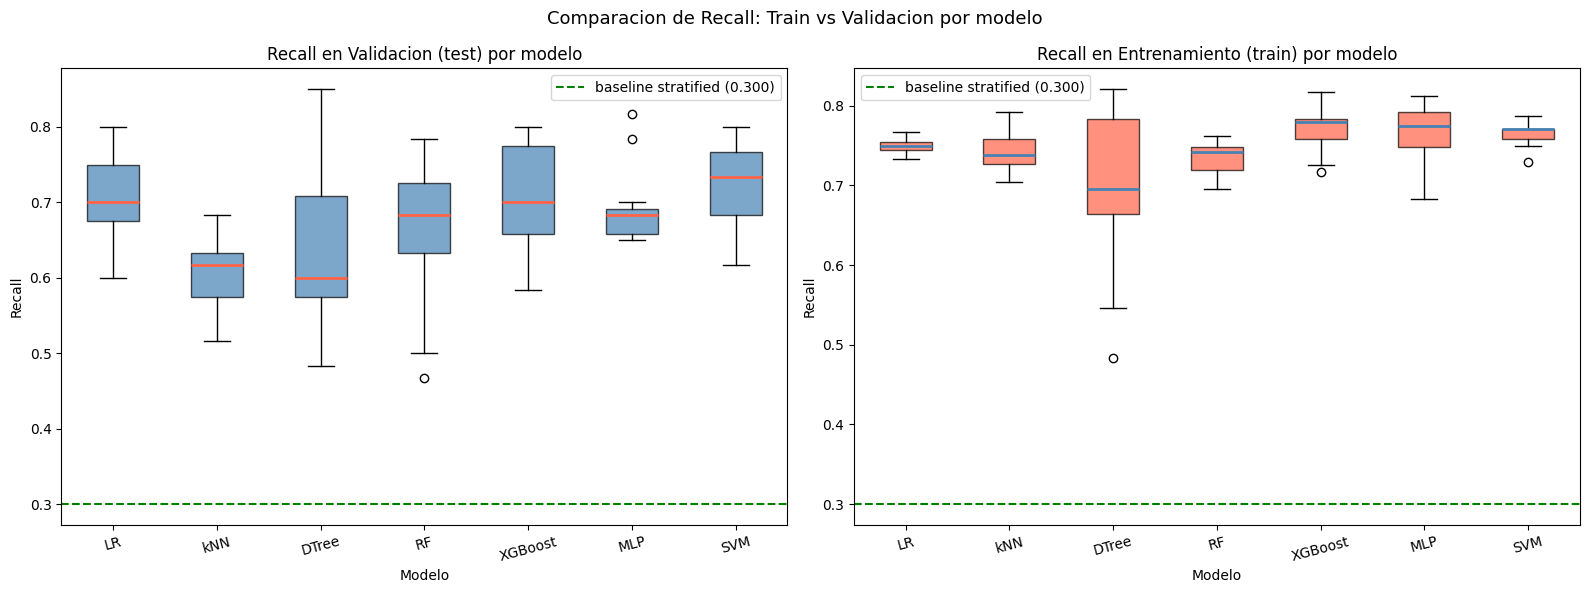

In [31]:
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall)

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

umbral_baseline = 0.3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

recall_test  = [resultados[i]['test_recall']  for i in range(len(nombres))]
recall_train = [resultados[i]['train_recall'] for i in range(len(nombres))]

# boxplot test recall
axes[0].boxplot(recall_test, labels=nombres, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='tomato', linewidth=2))
axes[0].axhline(umbral_baseline, color='green', linestyle='--', linewidth=1.5,
                label=f'baseline stratified ({umbral_baseline:.3f})')
axes[0].set_title('Recall en Validacion (test) por modelo')
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('Modelo')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# boxplot train recall
axes[1].boxplot(recall_train, labels=nombres, patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.7),
                medianprops=dict(color='steelblue', linewidth=2))
axes[1].axhline(umbral_baseline, color='green', linestyle='--', linewidth=1.5,
                label=f'baseline stratified ({umbral_baseline:.3f})')
axes[1].set_title('Recall en Entrenamiento (train) por modelo')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Modelo')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparacion de Recall: Train vs Validacion por modelo', fontsize=13)
plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

# **Ejercicio 10**


=== LR ===
              precision    recall  f1-score   support

   Bueno (0)       0.84      0.70      0.76       210
    Malo (1)       0.50      0.68      0.57        90

    accuracy                           0.70       300
   macro avg       0.67      0.69      0.67       300
weighted avg       0.73      0.70      0.71       300


=== kNN ===
              precision    recall  f1-score   support

   Bueno (0)       0.77      0.65      0.71       210
    Malo (1)       0.41      0.56      0.47        90

    accuracy                           0.62       300
   macro avg       0.59      0.60      0.59       300
weighted avg       0.66      0.62      0.64       300


=== DTree ===
              precision    recall  f1-score   support

   Bueno (0)       0.81      0.66      0.72       210
    Malo (1)       0.44      0.63      0.52        90

    accuracy                           0.65       300
   macro avg       0.62      0.65      0.62       300
weighted avg       0.70      0.65 

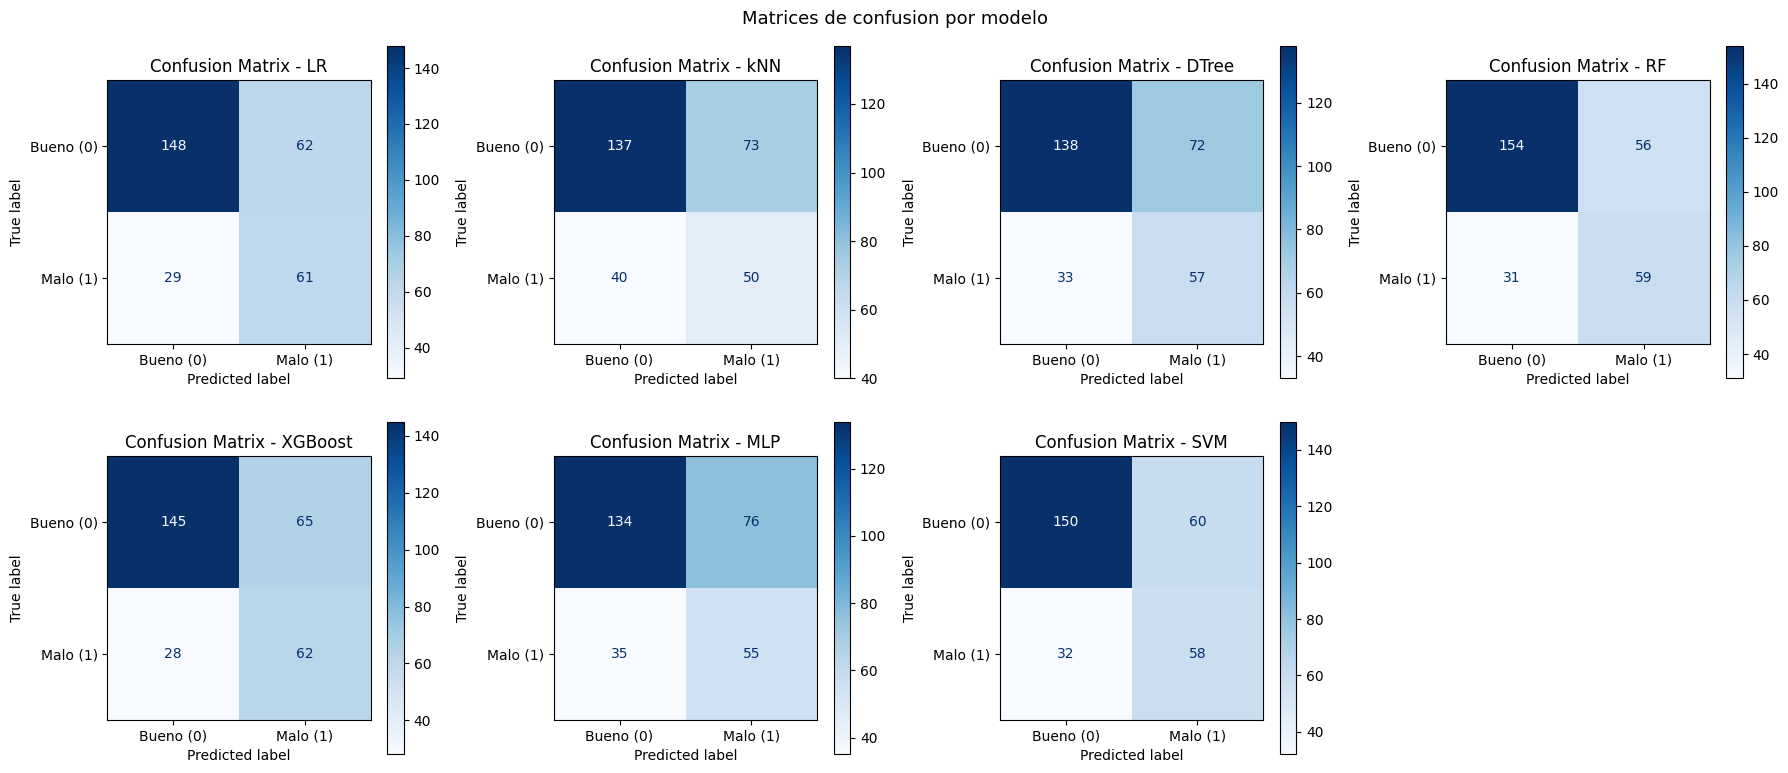

In [33]:
# 10a) Reporte de metricas

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# definimos todos los modelos con sus mejores hiperparametros
modelos_finales = {
    'LR'     : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', LogisticRegression(**mejores_params['LR'], random_state=1))]),
    'kNN'    : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='manhattan'))]),
    'DTree'  : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', DecisionTreeClassifier(**mejores_params['DTree'], random_state=1))]),
    'RF'     : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', RandomForestClassifier(**mejores_params['RF'], random_state=1))]),
    'XGBoost': ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', XGBClassifier(**mejores_params['XGBoost'], random_state=1, eval_metric='logloss'))]),
    'MLP'    : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', MLPClassifier(hidden_layer_sizes=(50,), activation='relu',
                                    alpha=0.01, max_iter=500, early_stopping=True, random_state=1))]),
    'SVM'    : ImbPipeline(steps=[('ct', columnasTransformer), ('uos', mi_uoSampling),
                ('m', SVC(**mejores_params['SVM'], random_state=1, probability=True))])
}

# entrenamos cada modelo con Xtrain y evaluamos en Xtest
resumen = []
for nombre, pipeline in modelos_finales.items():
    pipeline.fit(Xtrain, ytrain)
    y_pred = pipeline.predict(Xtest)
    y_prob = pipeline.predict_proba(Xtest)[:, 1] if hasattr(pipeline.named_steps['m'], 'predict_proba') else None

    acc  = accuracy_score(ytest, y_pred)
    rec  = recall_score(ytest, y_pred)
    prec = precision_score(ytest, y_pred)
    f1   = f1_score(ytest, y_pred)
    auc  = roc_auc_score(ytest, y_prob) if y_prob is not None else None

    resumen.append({
        'Modelo'    : nombre,
        'Accuracy'  : round(acc, 3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec, 3),
        'F1'        : round(f1, 3),
        'ROC-AUC'   : round(auc, 3) if auc else 'N/A'
    })

    print(f"\n=== {nombre} ===")
    print(classification_report(ytest, y_pred, target_names=['Bueno (0)', 'Malo (1)']))

# tabla resumen ordenada por recall
df_resumen = pd.DataFrame(resumen).sort_values('Recall', ascending=False)
print("\n=== Tabla resumen de todos los modelos (ordenada por Recall) ===\n")
print(df_resumen.to_string(index=False))

# identificamos el mejor modelo por recall
mejor_modelo_nombre = df_resumen.iloc[0]['Modelo']
print(f"\nMejor modelo por Recall: {mejor_modelo_nombre}")

# matrices de confusion de todos los modelos
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_finales.items()):
    y_pred = pipeline.predict(Xtest)
    ConfusionMatrixDisplay(confusion_matrix(ytest, y_pred),
                           display_labels=['Bueno (0)', 'Malo (1)']).plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix - {nombre}')

axes[-1].set_visible(False)
plt.suptitle('Matrices de confusion por modelo', fontsize=13)
plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

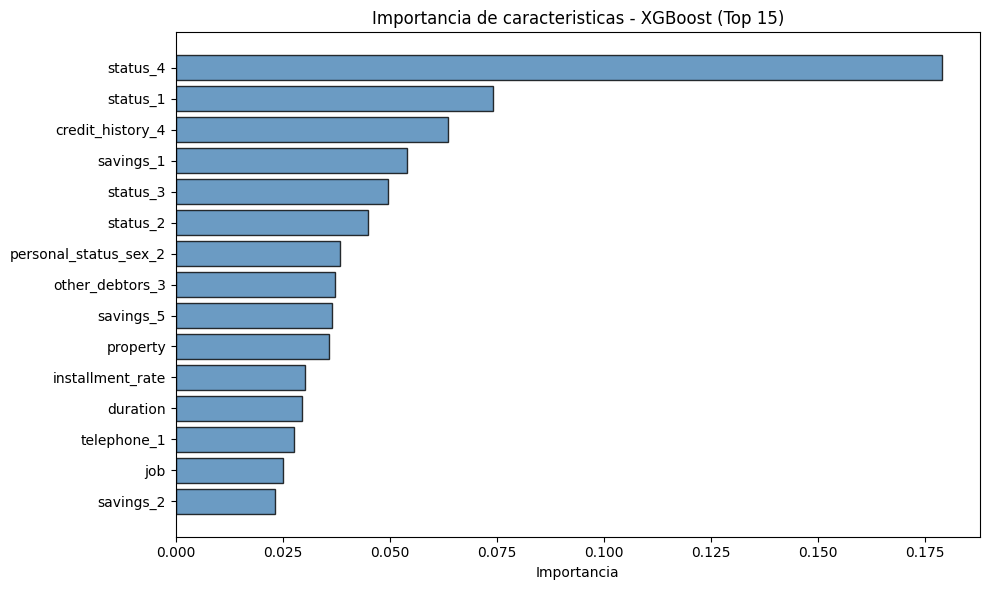


Top 15 caracteristicas mas importantes:
              feature  importance
             status_4    0.178927
             status_1    0.074105
     credit_history_4    0.063552
            savings_1    0.053942
             status_3    0.049632
             status_2    0.045012
personal_status_sex_2    0.038390
      other_debtors_3    0.037226
            savings_5    0.036563
             property    0.035784
     installment_rate    0.030109
             duration    0.029467
          telephone_1    0.027551
                  job    0.025157
            savings_2    0.023108


In [34]:
# 10b) Analisis de importancia de caracteristicas/factores

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# extraemos los nombres de las columnas tras el ColumnTransformer
num_features = list_paper_num
nom_features = modelos_finales['XGBoost'].named_steps['ct']\
               .named_transformers_['nom']\
               .named_steps['onehot']\
               .get_feature_names_out(list_paper_cat).tolist()
ord_features = list_paper_ord
all_features = num_features + nom_features + ord_features

# extraemos importancias del modelo XGBoost entrenado
xgb_model = modelos_finales['XGBoost'].named_steps['m']
importancias = xgb_model.feature_importances_

df_imp = pd.DataFrame({
    'feature'   : all_features,
    'importance': importancias
}).sort_values('importance', ascending=False).head(15)

# grafico
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_imp['feature'][::-1], df_imp['importance'][::-1],
        color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Importancia de caracteristicas - XGBoost (Top 15)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print("\nTop 15 caracteristicas mas importantes:")
print(df_imp.to_string(index=False))

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

* **10c) Incluye tus comentarios de los resultados obtenidos en los inciso previos de este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



**10c) Incluye tus comentarios de los resultados obtenidos en los inciso previos de este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

en el reporte de metricas se evaluaron los siete modelos entrenados sobre el conjunto de prueba. el modelo con mejor desempeño en recall fue XGBoost con un valor de 0.689 seguido de cerca por regresion logistica con 0.678 y random forest con 0.656. esto significa que XGBoost logro identificar correctamente cerca del 69% de los malos clientes reales en datos no vistos durante el entrenamiento. todos los modelos superaron ampliamente el umbral baseline de 0.30 lo que confirma que el proceso de entrenamiento fue exitoso y que los modelos aprendieron patrones utiles del problema.

en terminos de accuracy el mejor modelo fue random forest con 0.710 aunque la diferencia entre modelos es pequeña. el ROC-AUC mas alto tambien corresponde a XGBoost con 0.769 lo que indica que tiene la mejor capacidad general para separar buenos y malos clientes en distintos umbrales de decision. los modelos con menor desempeño general fueron kNN y MLP. el primero por su dificultad para generalizar en espacios de alta dimension y el segundo por ser mas sensible a la configuracion de hiperparametros.

las matrices de confusion muestran que todos los modelos tienen dificultades para reducir los falsos negativos. es decir malos clientes clasificados como buenos. XGBoost deja pasar 28 malos clientes de 90 mientras que kNN deja pasar 40. esto refleja la dificultad inherente del problema con datos desbalanceados incluso despues de aplicar SMOTE.

en cuanto al analisis de importancia de caracteristicas el modelo XGBoost identifica que las variables mas relevantes para sus decisiones son las categorias de status de cuenta bancaria especialmente status_4 con una importancia de 0.179 que representa casi el doble de la siguiente variable mas importante. esto es consistente con la intuicion financiera: el estado actual de la cuenta bancaria es el indicador mas directo del comportamiento de pago de un cliente. le siguen en importancia status_1 que representa clientes sin cuenta de cheques y credit_history_4 que indica clientes con historial impecable de pagos en el banco.

savings_1 tambien aparece entre las mas importantes lo que refleja que la ausencia de ahorros o informacion desconocida sobre los mismos genera incertidumbre en el modelo. en general las variables financieras directas como status savings y credit_history dominan sobre variables demograficas como age o personal_status_sex lo que sugiere que el comportamiento financiero pasado es mas predictivo del riesgo crediticio que las caracteristicas personales del solicitante.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 11**

### **Incluyan sus conclusiones finales de la actividad.**   

++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++




esta actividad permitio abordar el problema de prediccion de riesgo crediticio usando el dataset South German Credit desde una perspectiva practica de aprendizaje automatico siguiendo de cerca la metodologia propuesta en el articulo de la IEEE.

el primer hallazgo importante fue confirmar el desbalance de clases en los datos con 70% de buenos clientes y 30% de malos. este desbalance justifica tanto la eleccion del recall como metrica principal como el uso de tecnicas de sobremuestreo. en este caso SMOTE demostro ser una herramienta efectiva para balancear las clases durante el entrenamiento sin contaminar los datos de validacion gracias al uso correcto de pipelines que evitan el filtrado de informacion.

el analisis exploratorio resulto ser una etapa clave ya que permitio identificar desde antes del entrenamiento que variables como status savings y credit_history tenian mayor poder discriminativo. estos hallazgos fueron posteriormente confirmados por el analisis de importancia de caracteristicas de XGBoost donde estas mismas variables dominaron las decisiones del modelo. esto refuerza la idea de que el comportamiento financiero pasado es el mejor predictor del riesgo crediticio futuro.

en cuanto a los modelos evaluados XGBoost obtuvo el mejor recall de 0.689 y el mayor ROC-AUC de 0.769 siendo el modelo recomendado para este problema. la regresion logistica mostro un desempeño muy competitivo con mayor estabilidad y menor diferencia entre train y test lo que la convierte en una alternativa interesante cuando la interpretabilidad del modelo es prioritaria. kNN y MLP mostraron los peores resultados generales siendo kNN propenso al sobreentrenamiento y MLP sensible a la configuracion de hiperparametros.

es importante destacar que aun el mejor modelo deja pasar aproximadamente 31% de los malos clientes lo que indica que el problema sigue siendo desafiante. en un contexto real esto podria complementarse con un ajuste del umbral de decision del modelo para priorizar aun mas el recall a costa de reducir la precision segun el apetito de riesgo de la institucion financiera.

finalmente esta actividad deja en evidencia que el proceso de machine learning va mucho mas alla de entrenar modelos. la definicion correcta de la metrica de negocio el manejo adecuado del desbalance de clases la prevencion del filtrado de informacion y el analisis interpretable de los resultados son elementos igualmente importantes para construir soluciones utiles y confiables en problemas reales de riesgo crediticio.



++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **+++Fin de la Actividad con los datos de South_German_Credit+++**